In [1]:
from netCDF4 import Dataset
import datetime
import matplotlib
import pandas as pd
import os
import numpy as np
from scipy.signal import argrelextrema
import pickle
from ll_xy import lonlat_to_xy
import warnings
import matplotlib.pyplot as plt
import kuka_tools as kt
# You can find kuka_tools at https://github.com/robbiemallett/custom_modules/blob/master/kuka_tools.py

In [10]:
directory = '/media/robbie/One Touch/KUKA/KUKA_PROCESSED/20231006'

freqs=['ku','ka']
listfiles = os.listdir(directory)
files = {'ku':sorted([f for f in listfiles if f'Ku-Scat' in f]),
         'ka':sorted([f for f in listfiles if f'Ka-Scat' in f])}

files['ku'] =  [f for f in files['ku'] if "-1340"  in f]
files['ka'] =  [f for f in files['ka'] if "-1342"  in f]

kuka_stare_decon_Ku-Scat20231006-134008.nc 646
kuka_stare_decon_Ka-Scat20231006-134203.nc 1158


Text(0, 0.5, 'y distance (m)')

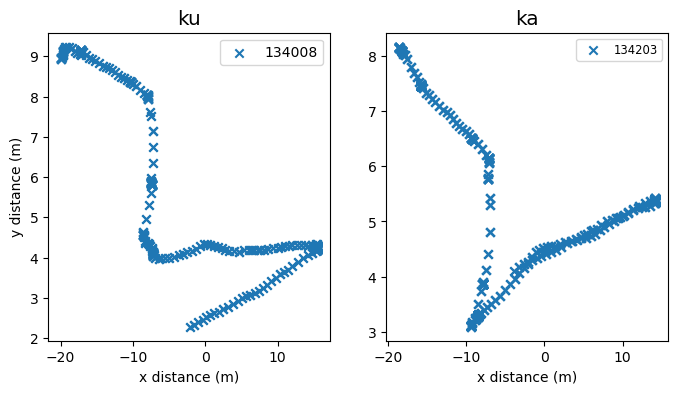

In [11]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,4))

xy_dict = {}

for freq, ax in zip(freqs,[ax1,ax2]):
    
    ax.set_title(freq,fontsize='x-large')
    
    x,y=kt.plot_pos(files['ku'][0],directory,plot=False)
    

    x0 = -2300414.994491106; y0 = 923485.871699531

    xy_dict[freq]={}
    
    for f in files[freq]:

        x,y = kt.plot_pos(f,directory,x0=x0,y0=y0,ax=ax)
        
        print(f,len(x))

        xy_dict[freq][f] = (x,y)

ax1.legend()
ax2.legend(ncol=2,fontsize='small')
ax1.set_xlabel('x distance (m)')
ax2.set_xlabel('x distance (m)')
ax1.set_ylabel('y distance (m)')

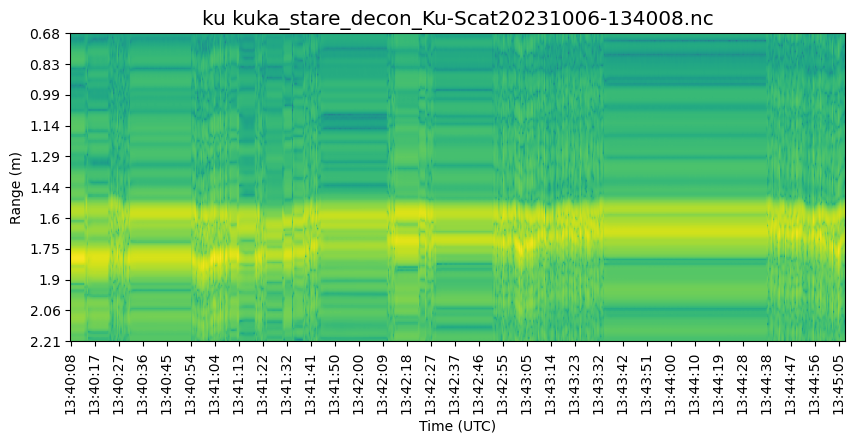

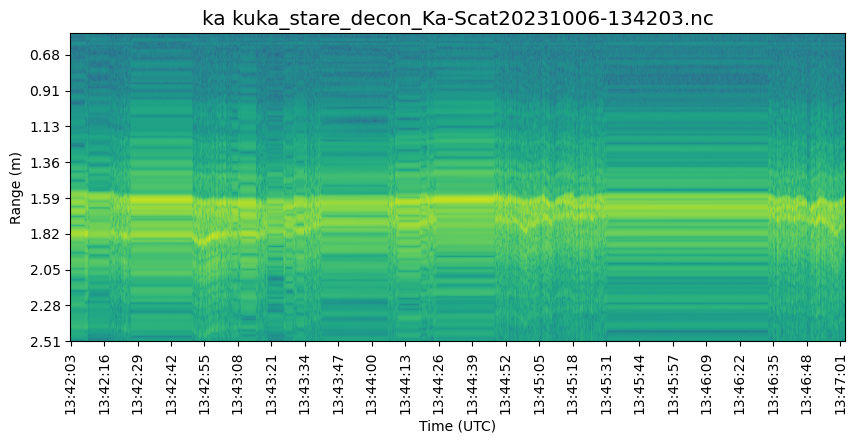

In [12]:

for freq in freqs:
    
    for f in files[freq]:
        kt.plot_file(f,freq.lower(),directory,
                         vlines=[])

In [15]:
nearfardict = {}

for freq in ['ku','ka']:
    
    file = files[freq][0]
    d = Dataset(f'{directory}/{file}')
    near=kt.get_range_index(1.3,d['range'])
    far=kt.get_range_index(2,d['range'])
    nearfardict[freq] = {'near':near,'far':far,'range':np.array(d['range'])[near:far]}

In [16]:
data = {}

for freq in ['ku','ka']:

    nrcs_list = []
    for foi in files[freq]:

        x,y=xy_dict[freq][foi]

        d = Dataset(f'{directory}/{foi}')

        time_offset_s=0
        times = np.array([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(x))+datetime.timedelta(seconds=int(time_offset_s)) for x in d['start_time']])

        mintime=0
        maxtime=100000

        nrcs = pd.DataFrame(kt.get_nrcs(d,freq.lower()))

        x_ = 0; y_ = 0

        # along_track = np.sqrt((x-x_)**2 + (y-y_)**2)
        xdiff = np.diff(x)
        ydiff = np.diff(y)
        speed = np.sqrt(np.square(xdiff)+np.square(ydiff))
        speed=list(speed)+[0]
        # nrcs['along_track']=along_track
        # nrcs['speed']=speed
        # nrcs['x']=x
        # nrcs['y']=y
        nrcs['xtilt']=np.array(d['cross_tilt'])
        nrcs['atilt']=np.array(d['along_tilt'])
        nrcs = nrcs.iloc[mintime:maxtime]

        vv= np.array(d['vv_power_decon0'])[nearfardict[freq]['near']:nearfardict[freq]['far'],
                                           mintime:maxtime]
        
        nrcs['vv'] = [vv[:,i] for i in range(vv.shape[1])]

        nrcs = nrcs[nrcs['corr']<0.99]

        # nrcs_list.append( nrcs.sort_values('along_track').reset_index() )
        nrcs_list.append( nrcs )
        

    data[freq] = pd.concat(nrcs_list)

In [17]:
thresh = 0.05

freq = 'ku'

df = data[freq]

npeaks = []

multi_peak_inds = {x:{} for x in range(1,5)}



for i in range(df.shape[0]):
    
    power = df['vv'].iloc[i]
    
    # Identify all peaks more than 10% of max power
    
    ### Identify the indexes of all local maxima
    
    max_inds = argrelextrema(power, np.greater)[0]
    
    ### Catalogue the characteristics of the local maxima
    
    list_of_dicts_for_df = [{'ind':q,'power':power[q],'range':nearfardict[freq]['range'][q]} for q in max_inds]
    
    ### Sort dataframe so most powerful peaks at top
    
    peaks_df = pd.DataFrame(list_of_dicts_for_df).sort_values('power',ascending=False)
    
    max_power = peaks_df.iloc[0]['power']
    
    # Calculate power of each peak relative to max power
    peaks_df['rel_power'] = [x/max_power for x in peaks_df['power']]
    
    # Filter out weak peaks with a threshold to remove sidelobes
    peaks_df = peaks_df[peaks_df['rel_power']>thresh]
    
    # Sort peaks into ascending range
    peaks_df = peaks_df.sort_values('range',ascending=True)
    
    # Log npeaks to main dataframe
    npeaks.append(peaks_df.shape[0])
    
    for pn in range(1,5):
        if peaks_df.shape[0] == pn:
            multi_peak_inds[pn][i] = peaks_df
        
df['npeaks']=npeaks

(array([ 36., 106.,   0.,  95.,   0.,  36.,  28.,   0.,   3.,   2.]),
 array([1. , 1.6, 2.2, 2.8, 3.4, 4. , 4.6, 5.2, 5.8, 6.4, 7. ]),
 <BarContainer object of 10 artists>)

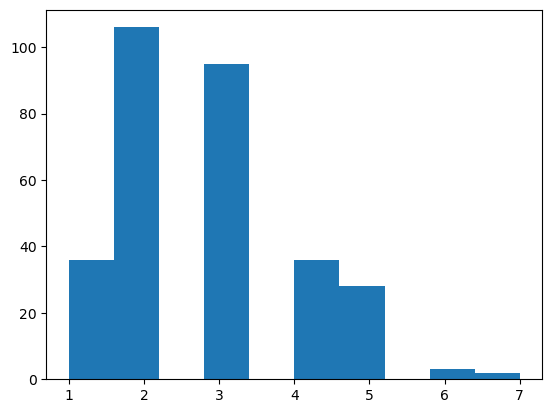

In [18]:
plt.hist(df['npeaks'])

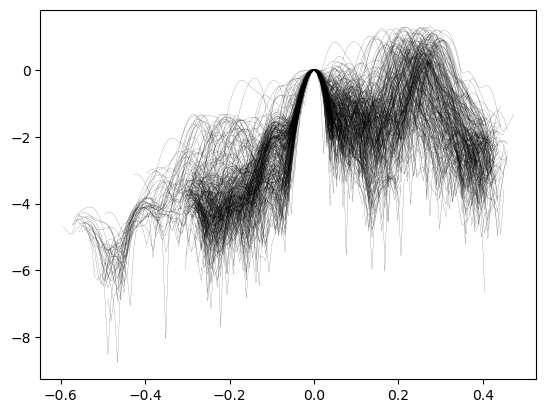

In [19]:
powers = []
shifts = []
peak1pow = []

ranges=nearfardict[freq]['range']

for pn in range(1,5):

    for i,peaks_df in multi_peak_inds[pn].items():

        power = df['vv'].iloc[i]
        
        powers.append(power)
        shifts.append(peaks_df.iloc[0]['ind'])
        peak1pow.append(peaks_df.iloc[0]['power'])
        
        plt.plot(ranges-peaks_df.iloc[0]['range'],
        # plt.plot(ranges,
                 np.log10(power/peaks_df.iloc[0]['power']),color='k',lw=0.1)
    
# plt.xlim(-0.1,0.4)

In [20]:
range_int=np.diff(nearfardict['ku']['range'])[0]
range_int

0.00762939453125

In [21]:
xaxis = np.arange(0,1000,range_int)[:60]-10*range_int

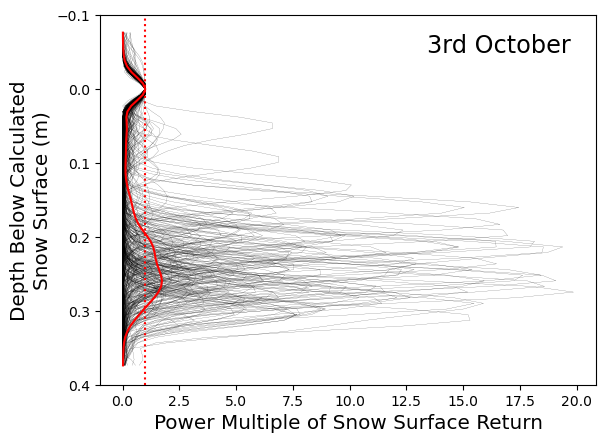

In [22]:
aligned_powers = []

for p,s,p1p in zip(powers,shifts,peak1pow):
    
    p_ = list([0]*(100-int(s)) + list(p)+[0]*100)[90:150]
    
    aligned_powers.append(p_/p1p)
    
    plt.plot(np.array(p_/p1p),xaxis,color='k',lw=0.1)
    
mean_pow = np.nanmean(aligned_powers,axis=0)

plt.plot(np.array(mean_pow),xaxis,color='r')
    
plt.ylim(0.4,-0.1)

plt.ylabel('Depth Below Calculated\nSnow Surface (m)',fontsize='x-large')

plt.xlabel('Power Multiple of Snow Surface Return',fontsize='x-large')

plt.axvline(1,color='r',ls=':')

plt.annotate('3rd October',xy=(0.95,0.95),ha='right',va='top',fontsize='xx-large',xycoords='axes fraction')

plt.savefig('3oct.png',dpi=500,bbox_inches='tight')

/tmp/ipykernel_1064/2075554975.py:9: RuntimeWarning: divide by zero encountered in log
  plt.plot(xaxis,np.log(p_/p1p),color='k',lw=0.1)


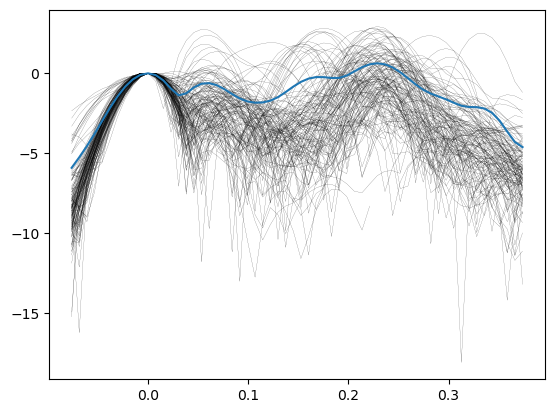

In [93]:
aligned_powers = []

for p,s,p1p in zip(powers,shifts,peak1pow):
    
    p_ = list([0]*(100-int(s)) + list(p)+[0]*100)[90:150]
    
    aligned_powers.append(p_/p1p)
    
    plt.plot(xaxis,np.log(p_/p1p),color='k',lw=0.1)
    
    
mean_pow = np.nanmean(aligned_powers,axis=0)

plt.plot(xaxis,np.log(mean_pow))
    

In [88]:
np.nanmean(np.array(aligned_powers))

0.0029895847569909166

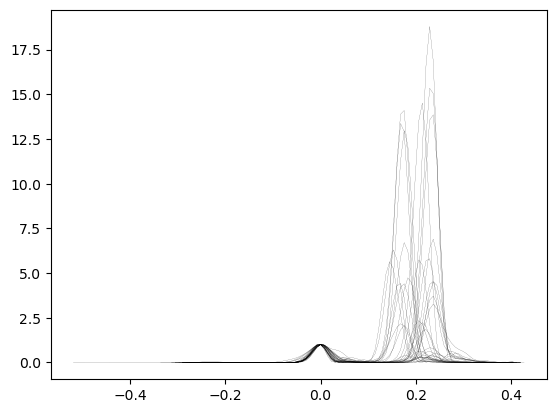

In [24]:
peak_separations = []
peak_ratios = []
p2_power = []
p1_power = []

ranges=nearfardict[freq]['range']

for i,peaks_df in double_peak_indices.items():
    
    power = df['vv'].iloc[i]

    peak_separations.append( np.diff(peaks_df['range'])[0] )
    
    peak_ratios.append(peaks_df.iloc[0]['power']/peaks_df.iloc[1]['power'])
    
    p2_power.append(peaks_df.iloc[1]['power'])
    p1_power.append(peaks_df.iloc[0]['power'])
    
    plt.plot(ranges-peaks_df.iloc[0]['range'],
             power/peaks_df.iloc[0]['power'],color='k',lw=0.1)
    
    
    
peak_ratios = np.array(peak_ratios)

In [ ]:
peak_separations = []
peak_ratios = []
p2_power = []
p1_power = []

ranges=nearfardict[freq]['range']

for i,peaks_df in double_peak_indices.items():
    
    power = df['vv'].iloc[i]

    peak_separations.append( np.diff(peaks_df['range'])[0] )
    
    peak_ratios.append(peaks_df.iloc[0]['power']/peaks_df.iloc[1]['power'])
    
    p2_power.append(peaks_df.iloc[1]['power'])
    p1_power.append(peaks_df.iloc[0]['power'])
    
    plt.plot(ranges-peaks_df.iloc[0]['range'],
             power/peaks_df.iloc[0]['power'],color='k',lw=0.1)
    
    
    
peak_ratios = np.array(peak_ratios)

Text(0, 0.5, 'y distance (m)')

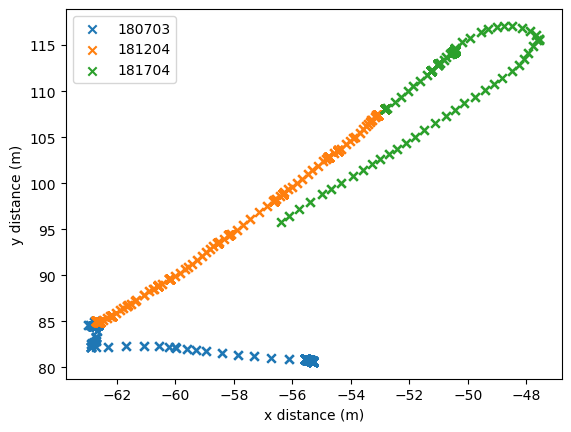

In [5]:
x0,y0 = 0,0

def plot_pos(file,plot=True,x0=0,y0=0):
    
    d = Dataset(f'{directory}/{file}')
    x, y = kt.lonlat_to_xy(np.array(d['lon']), np.array(d['lat']),hemisphere='s')
    y = y[np.abs(x)>10_000] -y0
    x = x[np.abs(x)>10_000] -x0
    if plot:
        plt.scatter(x,y,marker='x',label=file[-9:-3])

    return (x,y)

x,y=plot_pos('kuka_stare_decon_Ka-Scat20231002-135503.nc',plot=False)

x0 = x[0]; y0 = y[0]


# plot_pos('kuka_stare_decon_Ka-Scat20231002-180203.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231002-180703.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231002-181204.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231002-181704.nc',x0=x0,y0=y0)

plt.legend()
plt.xlabel('x distance (m)')
plt.ylabel('y distance (m)')

# plt.xlim(-20,5)
# plt.ylim(-20,5)

In [6]:
pits = {}

In [7]:
# # Offset between Ka & ku
fa = 'kuka_stare_decon_Ka-Scat20231002-181204.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181013.nc'

ka = Dataset(f'{directory}/{fa}')['start_time'][0]
ku = Dataset(f'{directory}/{fu}')['start_time'][0]
ka-ku

110.79099631309509

[]

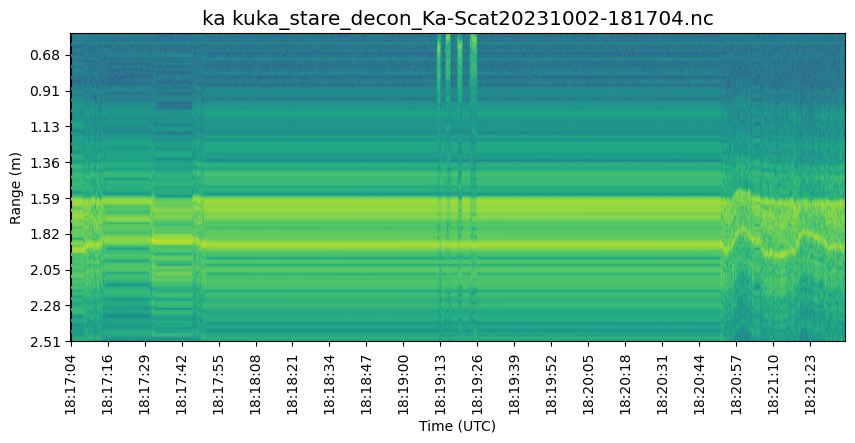

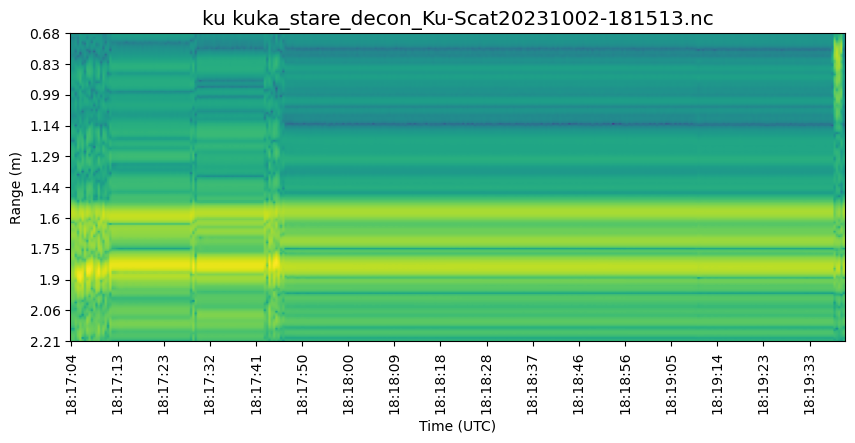

In [8]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181704.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181513.nc'

time_addition = datetime.timedelta(seconds=0)

ka_times = [(37,55)]
vlines = [datetime.datetime(2023,10,3,10,a,b)+time_addition for (a,b) in ka_times]
            # (30,30), (31,12)

kt.plot_file(fa,'ka',time_offset_s=0,vlines = vlines,directory=directory)

ku_times = []
vlines = [datetime.datetime(2023,10,2,11,a,b)+time_addition for (a,b) in ku_times]

kt.plot_file(fu,'ku',time_offset_s=-0+111,vlines=vlines,directory=directory)

datetime.timedelta(seconds=21109)

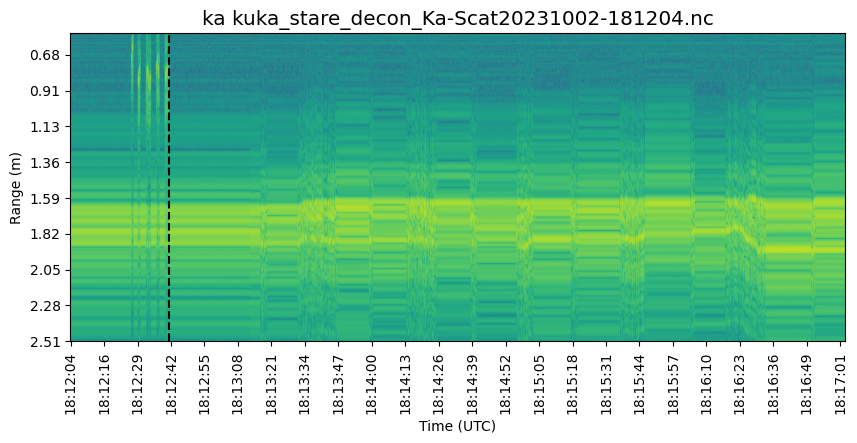

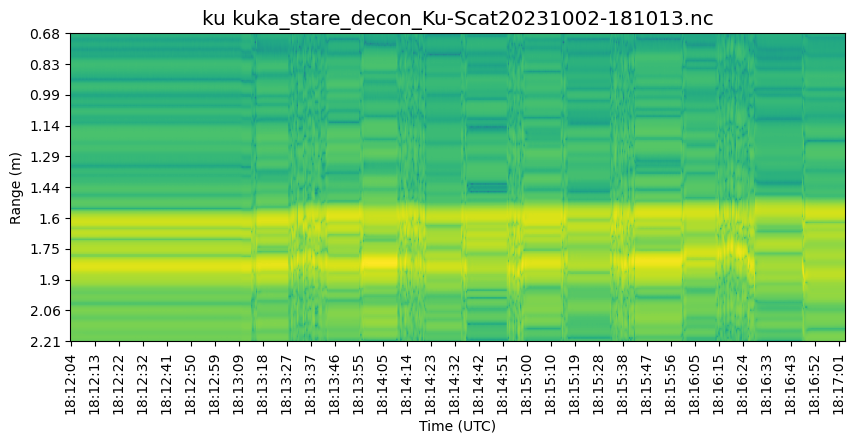

In [9]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181204.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181013.nc'

time_addition = datetime.timedelta(seconds=0)

ka_times = [(12,42)]
vlines = [datetime.datetime(2023,10,2,18,a,b)+time_addition for (a,b) in ka_times]

kt.plot_file(fa,'ka',time_offset_s=0,vlines = vlines,directory=directory)

ku_times = []
vlines = [datetime.datetime(2023,10,2,18,a,b)+time_addition for (a,b) in ku_times]

kt.plot_file(fu,'ku',time_offset_s=-0+111,vlines=vlines,directory=directory)

# Voice recording indicates that 18:12:42 kuka time is equal to 12:20:53 on phone

local_delta = datetime.datetime(2023,10,2,18,12,42)-datetime.datetime(2023,10,2,12,20,53)
local_delta

Loc 1
ka 12,21,07
ku 12,21,26

Loc 2
ka 12,21,55
ku 12,22,10

Loc 3
ka 12,22,32
ku 12,22,47

Loc 4
ka 12,23,10
ku 12,23,28

Loc 5
ka 12,23,54
ku 12,24,15

Loc 6
ka 12,24,51
ku 12,25,05

Loc 7
ka 12,25,25
ku 12,25,42

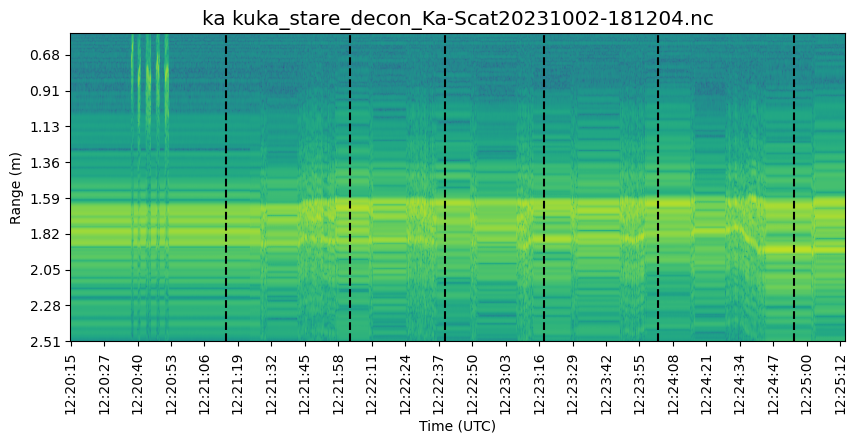

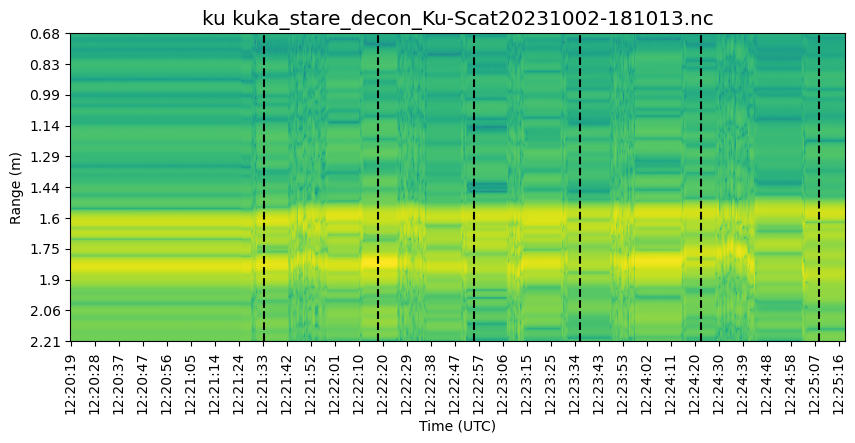

In [10]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181204.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181013.nc'

time_addition = datetime.timedelta(seconds=8)

ka_times = [(21,7),(21,55),(22,32),(23,10),(23,54),(24,47)] #Change last from (24,51) to (24,47)
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ka_times]
            # ,(25,25)

ka_inds = kt.plot_file(fa,'ka',time_offset_s=-local_delta.seconds,vlines = vlines,directory=directory)

ku_times = [(21,26),(22,10),(22,47),(23,28),(24,15),(25,1)]
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ku_times]
# ,(25,42)

ku_inds = kt.plot_file(fu,'ku',time_offset_s=-local_delta.seconds+115,vlines=vlines,directory=directory)

pit_numbers = [1,2,3,4,5,6]


ku_files = [fu]*len(pit_numbers)
ka_files = [fa]*len(pit_numbers)


for pitno, ka_ind, ku_ind, ka_file, ku_file in zip(pit_numbers,ka_inds,ku_inds,ka_files,ku_files):

    pits[pitno] = {}
    pits[pitno]['ka'] = ka_ind
    pits[pitno]['ku'] = ku_ind
    pits[pitno]['ka_file'] = ka_file
    pits[pitno]['ku_file'] = ku_file

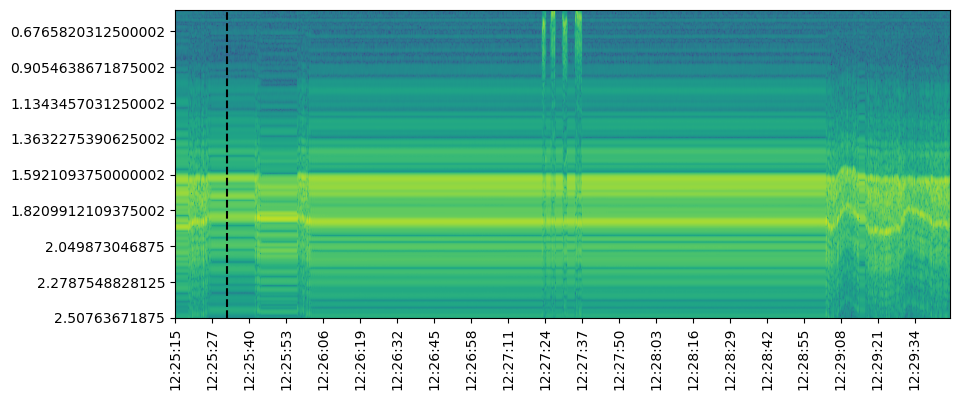

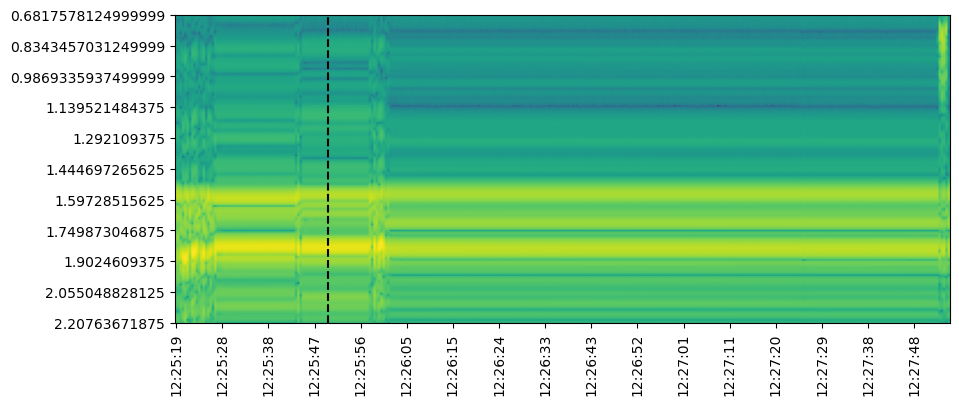

In [10]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181704.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181513.nc'

time_addition = datetime.timedelta(seconds=8)

ka_times = [(25,25)]
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ka_times]

ka_inds = kt.plot_file(fa,'ka',time_offset_s=-local_delta.seconds,vlines = vlines,directory=directory)

ku_times = [(25,42)]
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ku_times]

ku_inds = kt.plot_file(fu,'ku',time_offset_s=-local_delta.seconds+115,vlines=vlines,directory=directory)

pit_numbers = [7]


ku_files = [fu]*len(pit_numbers)
ka_files = [fa]*len(pit_numbers)


for pitno, ka_ind, ku_ind, ka_file, ku_file in zip(pit_numbers,ka_inds,ku_inds,ka_files,ku_files):

    pits[pitno] = {}
    pits[pitno]['ka'] = ka_ind
    pits[pitno]['ku'] = ku_ind
    pits[pitno]['ka_file'] = ka_file
    pits[pitno]['ku_file'] = ku_file

In [ ]:
pols = ['hh','vv',
        # 'hv','vh',
       ]

for pitno, data_dict in pits.items():

    y,m,day = kt.get_ymd_from_filename(pits[pitno]['ku_file'])
    
    for freq in ['ka','ku']:

        with Dataset(f'{directory}/{data_dict[f"{freq}_file"]}') as d:
            
            ranges = np.array(d['range'])

            start_ind = pits[pitno][freq]
            end_ind = start_ind+5

            for pol in pols:
            
                pits[pitno][f'{freq}_{pol}'] = np.mean(np.array(d[f'{pol}_power_decon0'])[:,start_ind:start_ind+5],axis=1)
                pits[pitno][f'{freq}_range'] = ranges

In [11]:
pols = ['hh','vv','hv','vh']

for pitno, data_dict in pits.items():

    y,m,day = kt.get_ymd_from_filename(pits[pitno]['ku_file'])
    
    for freq in ['ka','ku']:

        with Dataset(f'{directory}/{data_dict[f"{freq}_file"]}') as d:
            
            ranges = np.array(d['range'])

            start_ind = pits[pitno][freq]
            end_ind = start_ind+5

            for pol in pols:
            
                pits[pitno][f'{freq}_{pol}'] = np.mean(np.array(d[f'{pol}_power_decon0'])[:,start_ind:start_ind+5],axis=1)
                pits[pitno][f'{freq}_range'] = ranges

In [12]:
for freq in ['ka','ku']:

    for h in pits.keys():
    
        data = pits[h]
    
        dic = {pol:data[f'{freq}_{pol}'] for pol in pols}
        
        wvfms = pd.DataFrame(dic)
    
        wvfms.to_csv(f'../data/waveforms/Hangar_2023102_{h}_{freq}.csv')